# 🏋️ YOLO Classification – Fitness Dataset

**Mục tiêu:** Fine-tune mô hình YOLO (YOLOv8/YOLO11) cho bài toán **phân loại hình ảnh** (Classification) trên bộ dữ liệu Fitness.

---

## 📋 Nội dung Notebook

| Bước | Mô tả |
|------|-------|
| 1 | Cài đặt thư viện Ultralytics |
| 2 | Import & kiểm tra môi trường |
| 3 | Khám phá Dataset – đọc `data.yaml` |
| 4 | Chuyển đổi cấu trúc sang chuẩn YOLO Classification |
| 5 | Cấu hình & Huấn luyện mô hình |
| 6 | Đánh giá (Validation & Test) |
| 7 | Kết quả & Trực quan hóa |

---

> **Lưu ý về cấu trúc dữ liệu gốc:**  
> Dataset gốc (`archive/train|val|test/images` + `labels`) là định dạng **Object Detection**.  
> YOLO Classification yêu cầu mỗi class là một **thư mục riêng** chứa ảnh.  
> Notebook này sẽ tự động chuyển đổi sang đúng định dạng trước khi train.

## Bước 1 – Cài đặt Ultralytics

In [1]:
# Cài đặt / nâng cấp Ultralytics (bao gồm YOLOv8 và YOLO11)
!pip install -q ultralytics --upgrade

# Kiểm tra phiên bản
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.36


## Bước 2 – Import thư viện & Kiểm tra môi trường

In [2]:
import os
import shutil
import yaml
from pathlib import Path
from pprint import pprint

import torch
from ultralytics import YOLO
from ultralytics.utils import LOGGER

# ── Thông tin GPU ──────────────────────────────────────────────
print("=" * 55)
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("=" * 55)

# ── Đường dẫn gốc ─────────────────────────────────────────────
DATASET_ROOT = Path("/kaggle/input/datasets/anhqunhong/fitness-classification-dataset")
ARCHIVE_DIR  = DATASET_ROOT / "archive"
YAML_SRC     = DATASET_ROOT / "data.yaml"          # chỉ-đọc
WORKING_DIR  = Path("/kaggle/working")
CLS_DIR      = WORKING_DIR / "fitness_cls"          # thư mục chứa data đã chuyển đổi
YAML_CUSTOM  = WORKING_DIR / "data_custom.yaml"     # yaml sẽ dùng cho train

print(f"DATASET_ROOT : {DATASET_ROOT}")
print(f"ARCHIVE_DIR  : {ARCHIVE_DIR}")
print(f"YAML_SRC     : {YAML_SRC}")
print(f"CLS_DIR      : {CLS_DIR}")
print(f"YAML_CUSTOM  : {YAML_CUSTOM}")

PyTorch version  : 2.10.0+cu128
CUDA available   : True
GPU              : NVIDIA H100 80GB HBM3
VRAM             : 85.0 GB
DATASET_ROOT : /kaggle/input/datasets/anhqunhong/fitness-classification-dataset
ARCHIVE_DIR  : /kaggle/input/datasets/anhqunhong/fitness-classification-dataset/archive
YAML_SRC     : /kaggle/input/datasets/anhqunhong/fitness-classification-dataset/data.yaml
CLS_DIR      : /kaggle/working/fitness_cls
YAML_CUSTOM  : /kaggle/working/data_custom.yaml


## Bước 3 – Khám phá Dataset & Đọc `data.yaml`

In [3]:
# ── Đọc data.yaml gốc ─────────────────────────────────────────
with open(YAML_SRC, "r") as f:
    yaml_data = yaml.safe_load(f)

print("=== Nội dung data.yaml gốc ===")
pprint(yaml_data)

# Lấy thông tin class (KHÔNG thay đổi)
NUM_CLASSES = yaml_data.get("nc", None)
CLASS_NAMES = yaml_data.get("names", [])

print(f"\nSố lượng class (nc) : {NUM_CLASSES}")
print(f"Tên các class       : {CLASS_NAMES}")

=== Nội dung data.yaml gốc ===
{'names': {0: 'bench_pressing',
           1: 'front_raises',
           2: 'pull_ups',
           3: 'push_up',
           4: 'situp',
           5: 'rope_pushdown',
           6: 'deadlift',
           7: 'lunge',
           8: 'curl',
           9: 'squat'},
 'nc': 10,
 'path': '/kaggle/input/fitness-classification-dataset/archive',
 'test': 'test/images',
 'train': 'train/images',
 'val': 'val/images'}

Số lượng class (nc) : 10
Tên các class       : {0: 'bench_pressing', 1: 'front_raises', 2: 'pull_ups', 3: 'push_up', 4: 'situp', 5: 'rope_pushdown', 6: 'deadlift', 7: 'lunge', 8: 'curl', 9: 'squat'}


In [4]:
# ── Khám phá cấu trúc thư mục ─────────────────────────────────
splits = ["train", "val", "test"]

print("=== Thống kê ảnh trong từng split ===")
for split in splits:
    img_dir = ARCHIVE_DIR / split / "images"
    lbl_dir = ARCHIVE_DIR / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.rglob("*.*"))
        imgs = [p for p in imgs if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp", ".webp")]
        lbls = list(lbl_dir.rglob("*.txt")) if lbl_dir.exists() else []
        print(f"  {split:5s} | images: {len(imgs):5d} | labels: {len(lbls):5d}")
    else:
        print(f"  {split:5s} | KHÔNG TÌM THẤY thư mục: {img_dir}")

=== Thống kê ảnh trong từng split ===
  train | images: 11594 | labels: 11594
  val   | images:  2484 | labels:  2484
  test  | images:  2485 | labels:  2485


In [5]:
# ── Kiểm tra định dạng label để xác nhận là Object Detection ──
# (class_id cx cy w h  – mỗi dòng là 1 bbox)
sample_lbl_dir = ARCHIVE_DIR / "train" / "labels"
sample_labels  = list(sample_lbl_dir.glob("*.txt"))[:3]

print("=== Mẫu nội dung file label (Object Detection format) ===")
for lbl_path in sample_labels:
    print(f"\n[{lbl_path.name}]")
    with open(lbl_path) as f:
        content = f.read().strip()
    print(content[:300] if len(content) > 300 else content)

=== Mẫu nội dung file label (Object Detection format) ===

[crawl_00966.txt]
6

[crawl_06828.txt]
6

[crawl_03826.txt]
9


## Bước 4 – Chuyển đổi sang chuẩn YOLO Classification

**YOLO Classification** yêu cầu cấu trúc:
```
fitness_cls/
  train/
    class_0/   ← tên class
      img1.jpg
      ...
    class_1/
      ...
  val/
    class_0/
    ...
  test/
    class_0/
    ...
```

**Chiến lược:**  
- Mỗi ảnh trong Object Detection dataset có thể chứa nhiều đối tượng với nhiều class khác nhau.  
- Để chuyển sang Classification, ta chọn **class xuất hiện nhiều nhất** (majority class) trong file `.txt` tương ứng làm nhãn phân loại của ảnh đó.  
- Nếu file label rỗng (background), ảnh sẽ bị bỏ qua.  
- Ảnh được **copy** (không move) để giữ nguyên dữ liệu gốc.

In [6]:
from collections import Counter
import shutil

def get_majority_class(label_path: Path) -> int | None:
    """Đọc file label YOLO OD và trả về class_id xuất hiện nhiều nhất.
    Trả về None nếu file rỗng hoặc không hợp lệ.
    """
    try:
        lines = label_path.read_text().strip().splitlines()
        classes = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 1:
                try:
                    classes.append(int(parts[0]))
                except ValueError:
                    continue
        if not classes:
            return None
        return Counter(classes).most_common(1)[0][0]
    except Exception:
        return None

def convert_od_to_cls(
    archive_dir: Path,
    cls_dir: Path,
    class_names: list | dict,
    splits: list = ("train", "val", "test"),
) -> dict:
    """Chuyển đổi cấu trúc OD → Classification cho YOLO."""
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}
    stats = {}
    
    # Lấy danh sách tên class an toàn (hỗ trợ cả dict và list)
    valid_class_names = list(class_names.values()) if isinstance(class_names, dict) else class_names

    for split in splits:
        img_dir = archive_dir / split / "images"
        lbl_dir = archive_dir / split / "labels"

        if not img_dir.exists():
            print(f"[WARN] Không tìm thấy: {img_dir} – bỏ qua split '{split}'.")
            continue

        # [ĐÃ FIX] Tạo thư mục đích cho từng class và ép sang kiểu chuỗi (str)
        for cls_name in valid_class_names:
            (cls_dir / split / str(cls_name)).mkdir(parents=True, exist_ok=True)

        split_stats: dict[str, int] = Counter()
        skipped = 0

        for img_path in sorted(img_dir.iterdir()):
            if img_path.suffix.lower() not in IMG_EXTS:
                continue

            lbl_path = lbl_dir / (img_path.stem + ".txt")

            if not lbl_path.exists():
                skipped += 1
                continue

            class_id = get_majority_class(lbl_path)

            if class_id is None or class_id >= len(class_names):
                skipped += 1
                continue

            # [ĐÃ FIX] Đảm bảo tên thư mục luôn là chuỗi
            cls_name = str(class_names[class_id])
            dst = cls_dir / split / cls_name / img_path.name

            if not dst.exists():
                shutil.copy2(img_path, dst)

            split_stats[cls_name] += 1

        stats[split] = dict(split_stats)
        total = sum(split_stats.values())
        print(f"[{split:5s}] Đã xử lý {total} ảnh | Bỏ qua {skipped} ảnh")
        for cls, cnt in sorted(split_stats.items()):
            print(f"         {cls}: {cnt}")

    return stats

# Gọi hàm để thực thi việc chuyển đổi dữ liệu
print("Bắt đầu chuyển đổi dữ liệu...")
conversion_stats = convert_od_to_cls(
    archive_dir=ARCHIVE_DIR,
    cls_dir=CLS_DIR,
    class_names=CLASS_NAMES,
    splits=["train", "val", "test"]
)
print("✅ Chuyển đổi hoàn tất!")

Bắt đầu chuyển đổi dữ liệu...
[train] Đã xử lý 11562 ảnh | Bỏ qua 32 ảnh
         bench_pressing: 697
         deadlift: 3963
         front_raises: 1337
         pull_ups: 756
         push_up: 1037
         rope_pushdown: 868
         situp: 853
         squat: 2051
[val  ] Đã xử lý 2484 ảnh | Bỏ qua 0 ảnh
         bench_pressing: 166
         deadlift: 854
         front_raises: 280
         pull_ups: 186
         push_up: 224
         rope_pushdown: 159
         situp: 211
         squat: 404
[test ] Đã xử lý 2485 ảnh | Bỏ qua 0 ảnh
         bench_pressing: 147
         deadlift: 827
         front_raises: 306
         pull_ups: 192
         push_up: 224
         rope_pushdown: 183
         situp: 170
         squat: 436
✅ Chuyển đổi hoàn tất!


In [7]:
# ── Xác minh cấu trúc thư mục đầu ra ─────────────────────────
print("=== Cấu trúc thư mục fitness_cls/ ===")
for split in ["train", "val", "test"]:
    split_dir = CLS_DIR / split
    if not split_dir.exists():
        continue
    print(f"\n{split}/")
    for cls_dir_path in sorted(split_dir.iterdir()):
        if cls_dir_path.is_dir():
            n_imgs = len(list(cls_dir_path.glob("*.*")))
            print(f"  {cls_dir_path.name}/  ({n_imgs} ảnh)")

=== Cấu trúc thư mục fitness_cls/ ===

train/
  bench_pressing/  (697 ảnh)
  curl/  (0 ảnh)
  deadlift/  (3963 ảnh)
  front_raises/  (1337 ảnh)
  lunge/  (0 ảnh)
  pull_ups/  (756 ảnh)
  push_up/  (1037 ảnh)
  rope_pushdown/  (868 ảnh)
  situp/  (853 ảnh)
  squat/  (2051 ảnh)

val/
  bench_pressing/  (166 ảnh)
  curl/  (0 ảnh)
  deadlift/  (854 ảnh)
  front_raises/  (280 ảnh)
  lunge/  (0 ảnh)
  pull_ups/  (186 ảnh)
  push_up/  (224 ảnh)
  rope_pushdown/  (159 ảnh)
  situp/  (211 ảnh)
  squat/  (404 ảnh)

test/
  bench_pressing/  (147 ảnh)
  curl/  (0 ảnh)
  deadlift/  (827 ảnh)
  front_raises/  (306 ảnh)
  lunge/  (0 ảnh)
  pull_ups/  (192 ảnh)
  push_up/  (224 ảnh)
  rope_pushdown/  (183 ảnh)
  situp/  (170 ảnh)
  squat/  (436 ảnh)


## Bước 5 – Cấu hình Model & Huấn luyện

### Lựa chọn Model

| Model | Kích thước | Phù hợp |
|-------|-----------|----------|
| `yolov8n-cls` | ~3 MB | Nhanh, GPU yếu / test nhanh |
| `yolov8s-cls` | ~22 MB | Cân bằng tốc độ & độ chính xác |
| `yolov8m-cls` | ~53 MB | Độ chính xác cao hơn |
| `yolo11s-cls` | ~18 MB | YOLO11, architecture mới nhất |

> Mặc định notebook dùng **`yolov8s-cls`**. Thay đổi biến `MODEL_NAME` nếu cần.

In [8]:
# ══════════════════════════════════════════════════════════════
#  ⚙️  CẤU HÌNH – Thay đổi tại đây nếu cần
# ══════════════════════════════════════════════════════════════

MODEL_NAME  = "yolo11s-cls.pt"   # backbone pretrained từ ImageNet
EPOCHS      = 50                  # Số epoch huấn luyện
IMG_SIZE    = 224                 # Kích thước ảnh đầu vào (224 phổ biến cho CLS)
BATCH_SIZE  = 32                  # Batch size (giảm xuống 16 nếu OOM)
LR0         = 1e-3                # Learning rate ban đầu
PATIENCE    = 10                  # Early stopping patience
NUM_WORKERS = 4                   # Số worker cho DataLoader
PROJECT     = "/kaggle/working/runs/classify"
EXP_NAME    = "fitness_yolo_cls"

# ══════════════════════════════════════════════════════════════

DEVICE = "0" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị huấn luyện : {DEVICE}")
print(f"Model               : {MODEL_NAME}")
print(f"Epochs              : {EPOCHS}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Image size          : {IMG_SIZE}")
print(f"Dữ liệu train từ    : {CLS_DIR}")

Thiết bị huấn luyện : 0
Model               : yolov8s-cls.pt
Epochs              : 50
Batch size          : 32
Image size          : 224
Dữ liệu train từ    : /kaggle/working/fitness_cls


In [9]:
# ── Khởi tạo model YOLO Classification ───────────────────────
# YOLO tự động nhận diện task=classify khi load model *-cls.pt
model = YOLO(MODEL_NAME)

print(f"Task: {model.task}")
print(f"Model info:")
model.info(verbose=False)

Task: classify
Model info:


In [10]:
# ── Huấn luyện ────────────────────────────────────────────────
# Đối với YOLO Classification, tham số `data` trỏ đến thư mục
# chứa các split (train/ val/ test/) – mỗi split có sub-folder
# theo tên class. KHÔNG cần file yaml riêng cho CLS task.

results = model.train(
    data=str(CLS_DIR),          # thư mục gốc chứa train/ val/ test/
    task="classify",            # bắt buộc chỉ định task
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=LR0,
    patience=PATIENCE,
    workers=NUM_WORKERS,
    device=DEVICE,
    project=PROJECT,
    name=EXP_NAME,
    exist_ok=True,
    pretrained=True,            # sử dụng pretrained weights
    optimizer="AdamW",          # AdamW thường hội tụ tốt hơn SGD với CLS
    cos_lr=True,                # cosine LR scheduler
    label_smoothing=0.1,        # giảm overfitting
    dropout=0.2,                # regularization
    augment=True,               # augmentation mạnh hơn
    verbose=True,
)

print("\n✅ Huấn luyện hoàn tất!")
print(f"Best model lưu tại: {results.save_dir}")

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/fitness_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fitness_yolo_cls, nbs=64, 

## Bước 6 – Đánh giá (Validation & Test)

In [11]:
# ── Load best model để đánh giá ───────────────────────────────
best_model_path = Path(PROJECT) / EXP_NAME / "weights" / "best.pt"
print(f"Đang tải best model: {best_model_path}")

best_model = YOLO(str(best_model_path))
print("✅ Tải model thành công.")

Đang tải best model: /kaggle/working/runs/classify/fitness_yolo_cls/weights/best.pt
✅ Tải model thành công.


In [12]:
# ── Validation trên tập VAL ───────────────────────────────────
print("=" * 55)
print("Đánh giá trên tập VAL")
print("=" * 55)

val_metrics = best_model.val(
    data=str(CLS_DIR),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    verbose=True,
)

print(f"\nTop-1 Accuracy (val): {val_metrics.top1:.4f}")
print(f"Top-5 Accuracy (val): {val_metrics.top5:.4f}")

Đánh giá trên tập VAL
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,088,010 parameters, 0 gradients, 12.5 GFLOPs
ERROR ❌ train: /kaggle/working/fitness_cls/train... found 11562 images in 8 classes (requires 10 classes, not 8)
ERROR ❌ val: /kaggle/working/fitness_cls/val... found 2484 images in 8 classes (requires 10 classes, not 8)
ERROR ❌ test: /kaggle/working/fitness_cls/test... found 2485 images in 8 classes (requires 10 classes, not 8)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2995.5±1423.3 MB/s, size: 106.3 KB)
val: Scanning /kaggle/working/fitness_cls/val... 2484 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2484/2484 1.2Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 78/78 29.9it/s 2.6s0.1s
                   all       0.99      0.999
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/v

In [13]:
# ── Validation trên tập TEST ──────────────────────────────────
print("=" * 55)
print("Đánh giá trên tập TEST")
print("=" * 55)

test_dir = CLS_DIR / "test"

if test_dir.exists():
    test_metrics = best_model.val(
        data=str(CLS_DIR),
        split="test",
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        verbose=True,
    )
    print(f"\nTop-1 Accuracy (test): {test_metrics.top1:.4f}")
    print(f"Top-5 Accuracy (test): {test_metrics.top5:.4f}")
else:
    print(f"[WARN] Không tìm thấy thư mục test: {test_dir}")

Đánh giá trên tập TEST
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
ERROR ❌ train: /kaggle/working/fitness_cls/train... found 11562 images in 8 classes (requires 10 classes, not 8)
ERROR ❌ val: /kaggle/working/fitness_cls/val... found 2484 images in 8 classes (requires 10 classes, not 8)
ERROR ❌ test: /kaggle/working/fitness_cls/test... found 2485 images in 8 classes (requires 10 classes, not 8)
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2615.9±931.1 MB/s, size: 71.9 KB)
test: Scanning /kaggle/working/fitness_cls/test... 2485 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2485/2485 5.8Kit/s 0.4s0.0s
test: New cache created: /kaggle/working/fitness_cls/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 78/78 29.0it/s 2.7s0.1s
                   all      0.985      0.999
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val2

Top-1 Accura

## Bước 7 – Kết quả & Trực quan hóa


📊 results.png


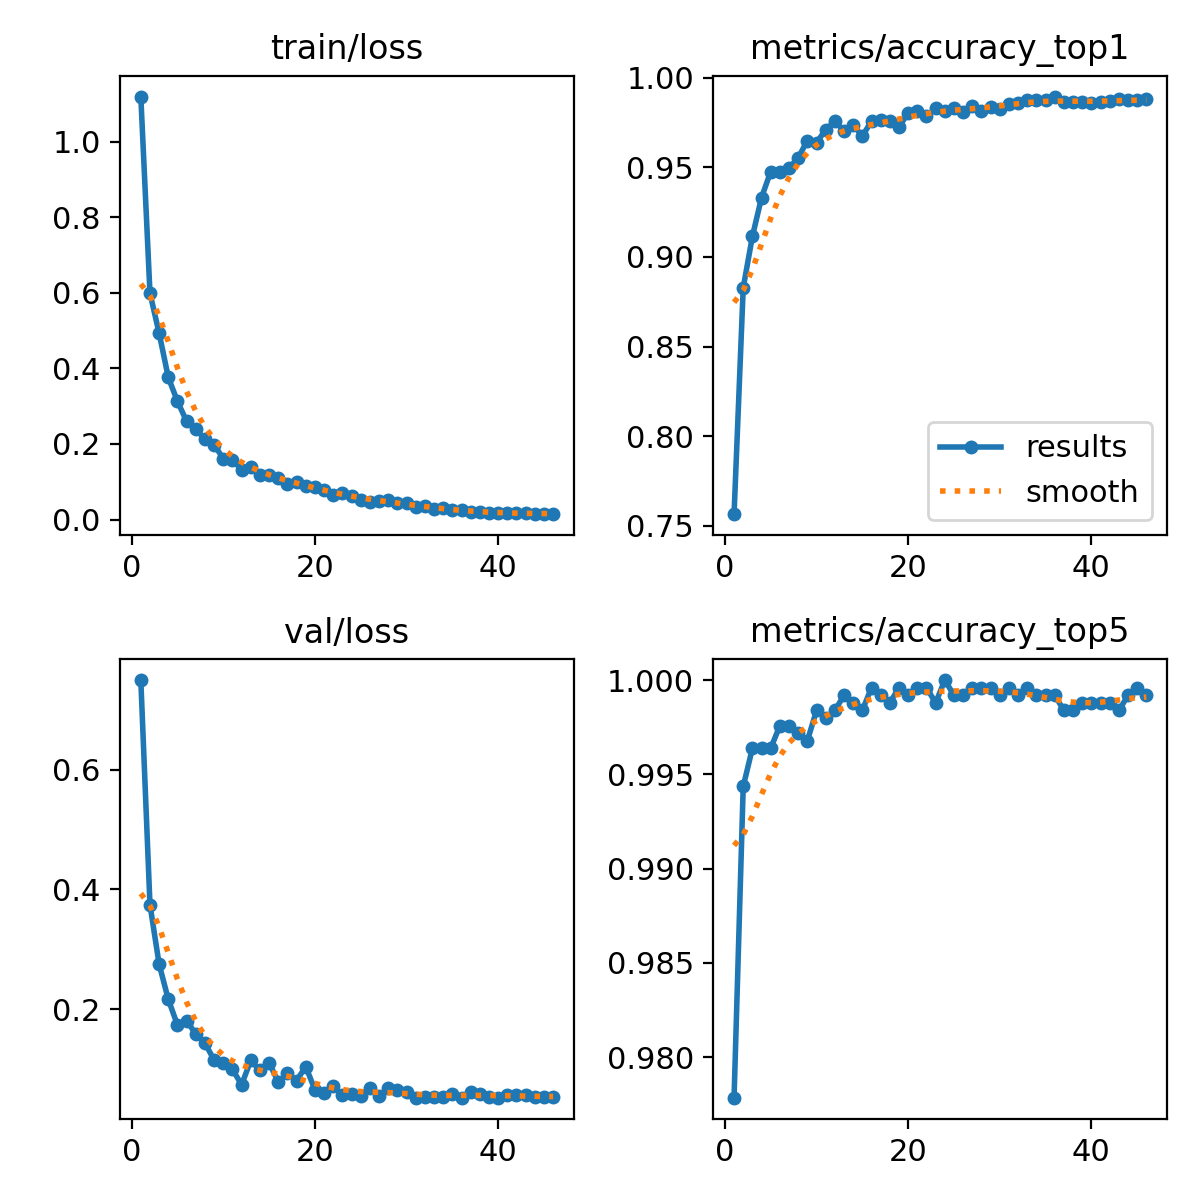


📊 confusion_matrix_normalized.png


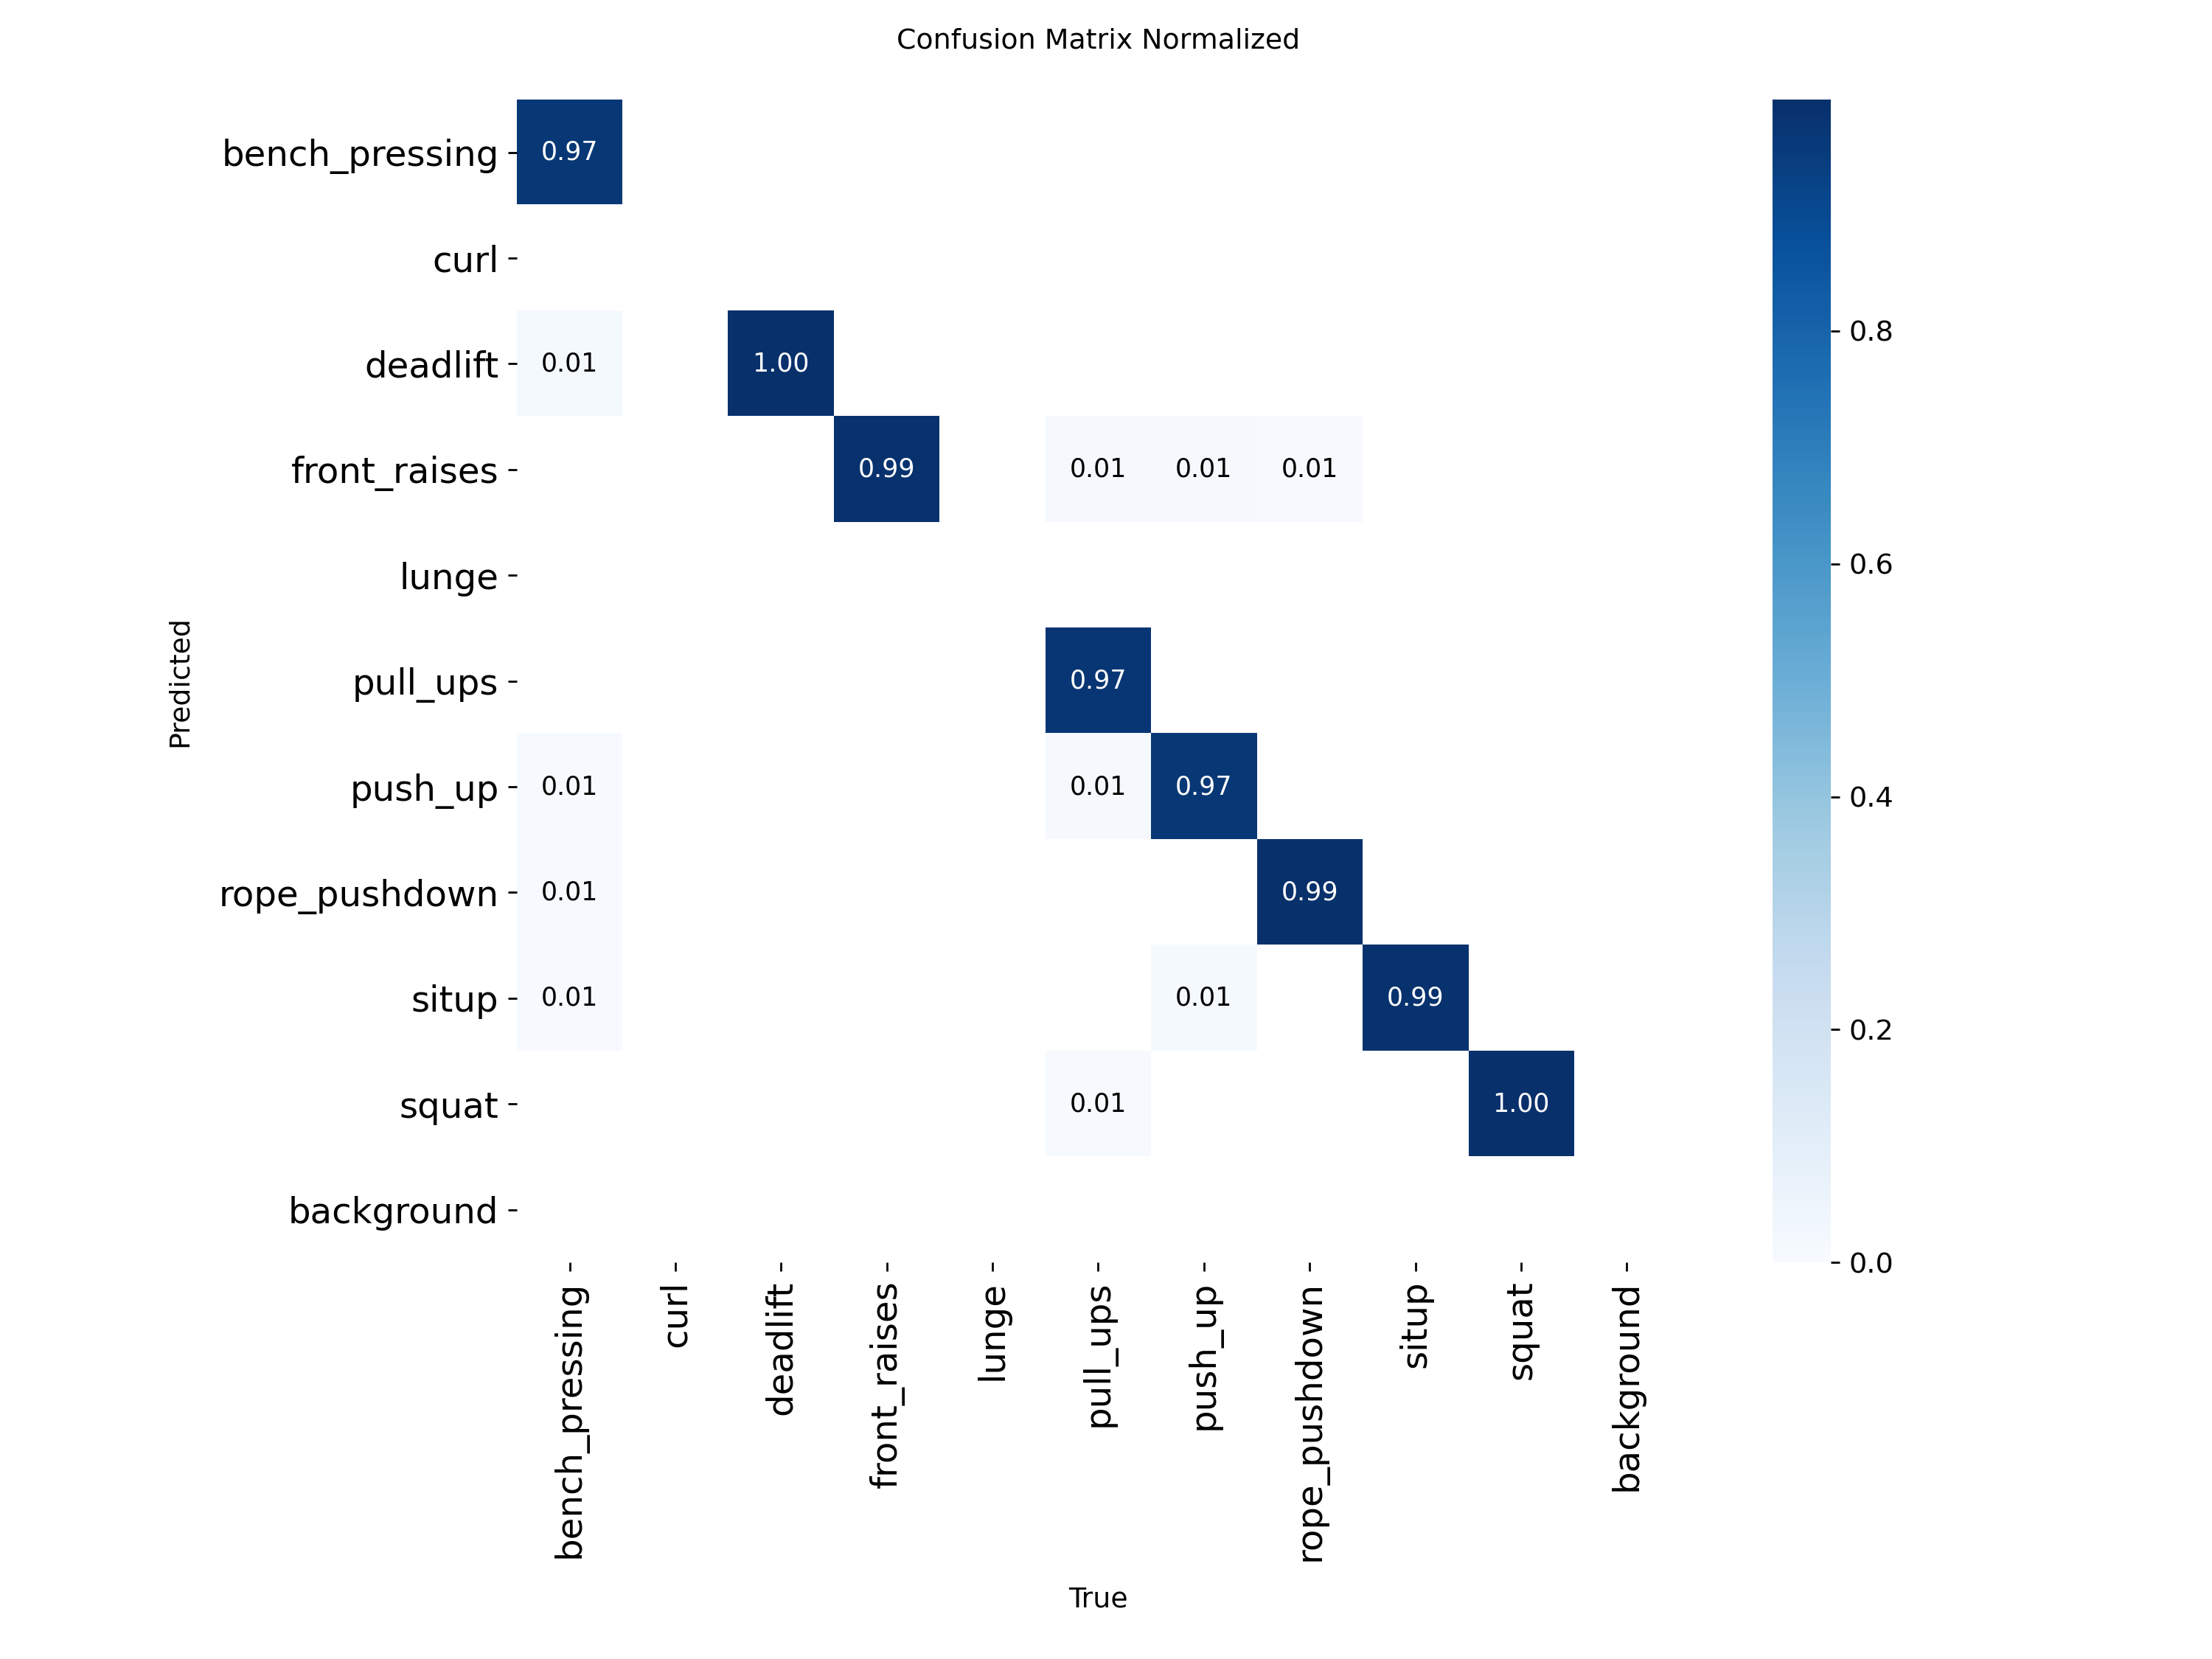


📊 confusion_matrix.png


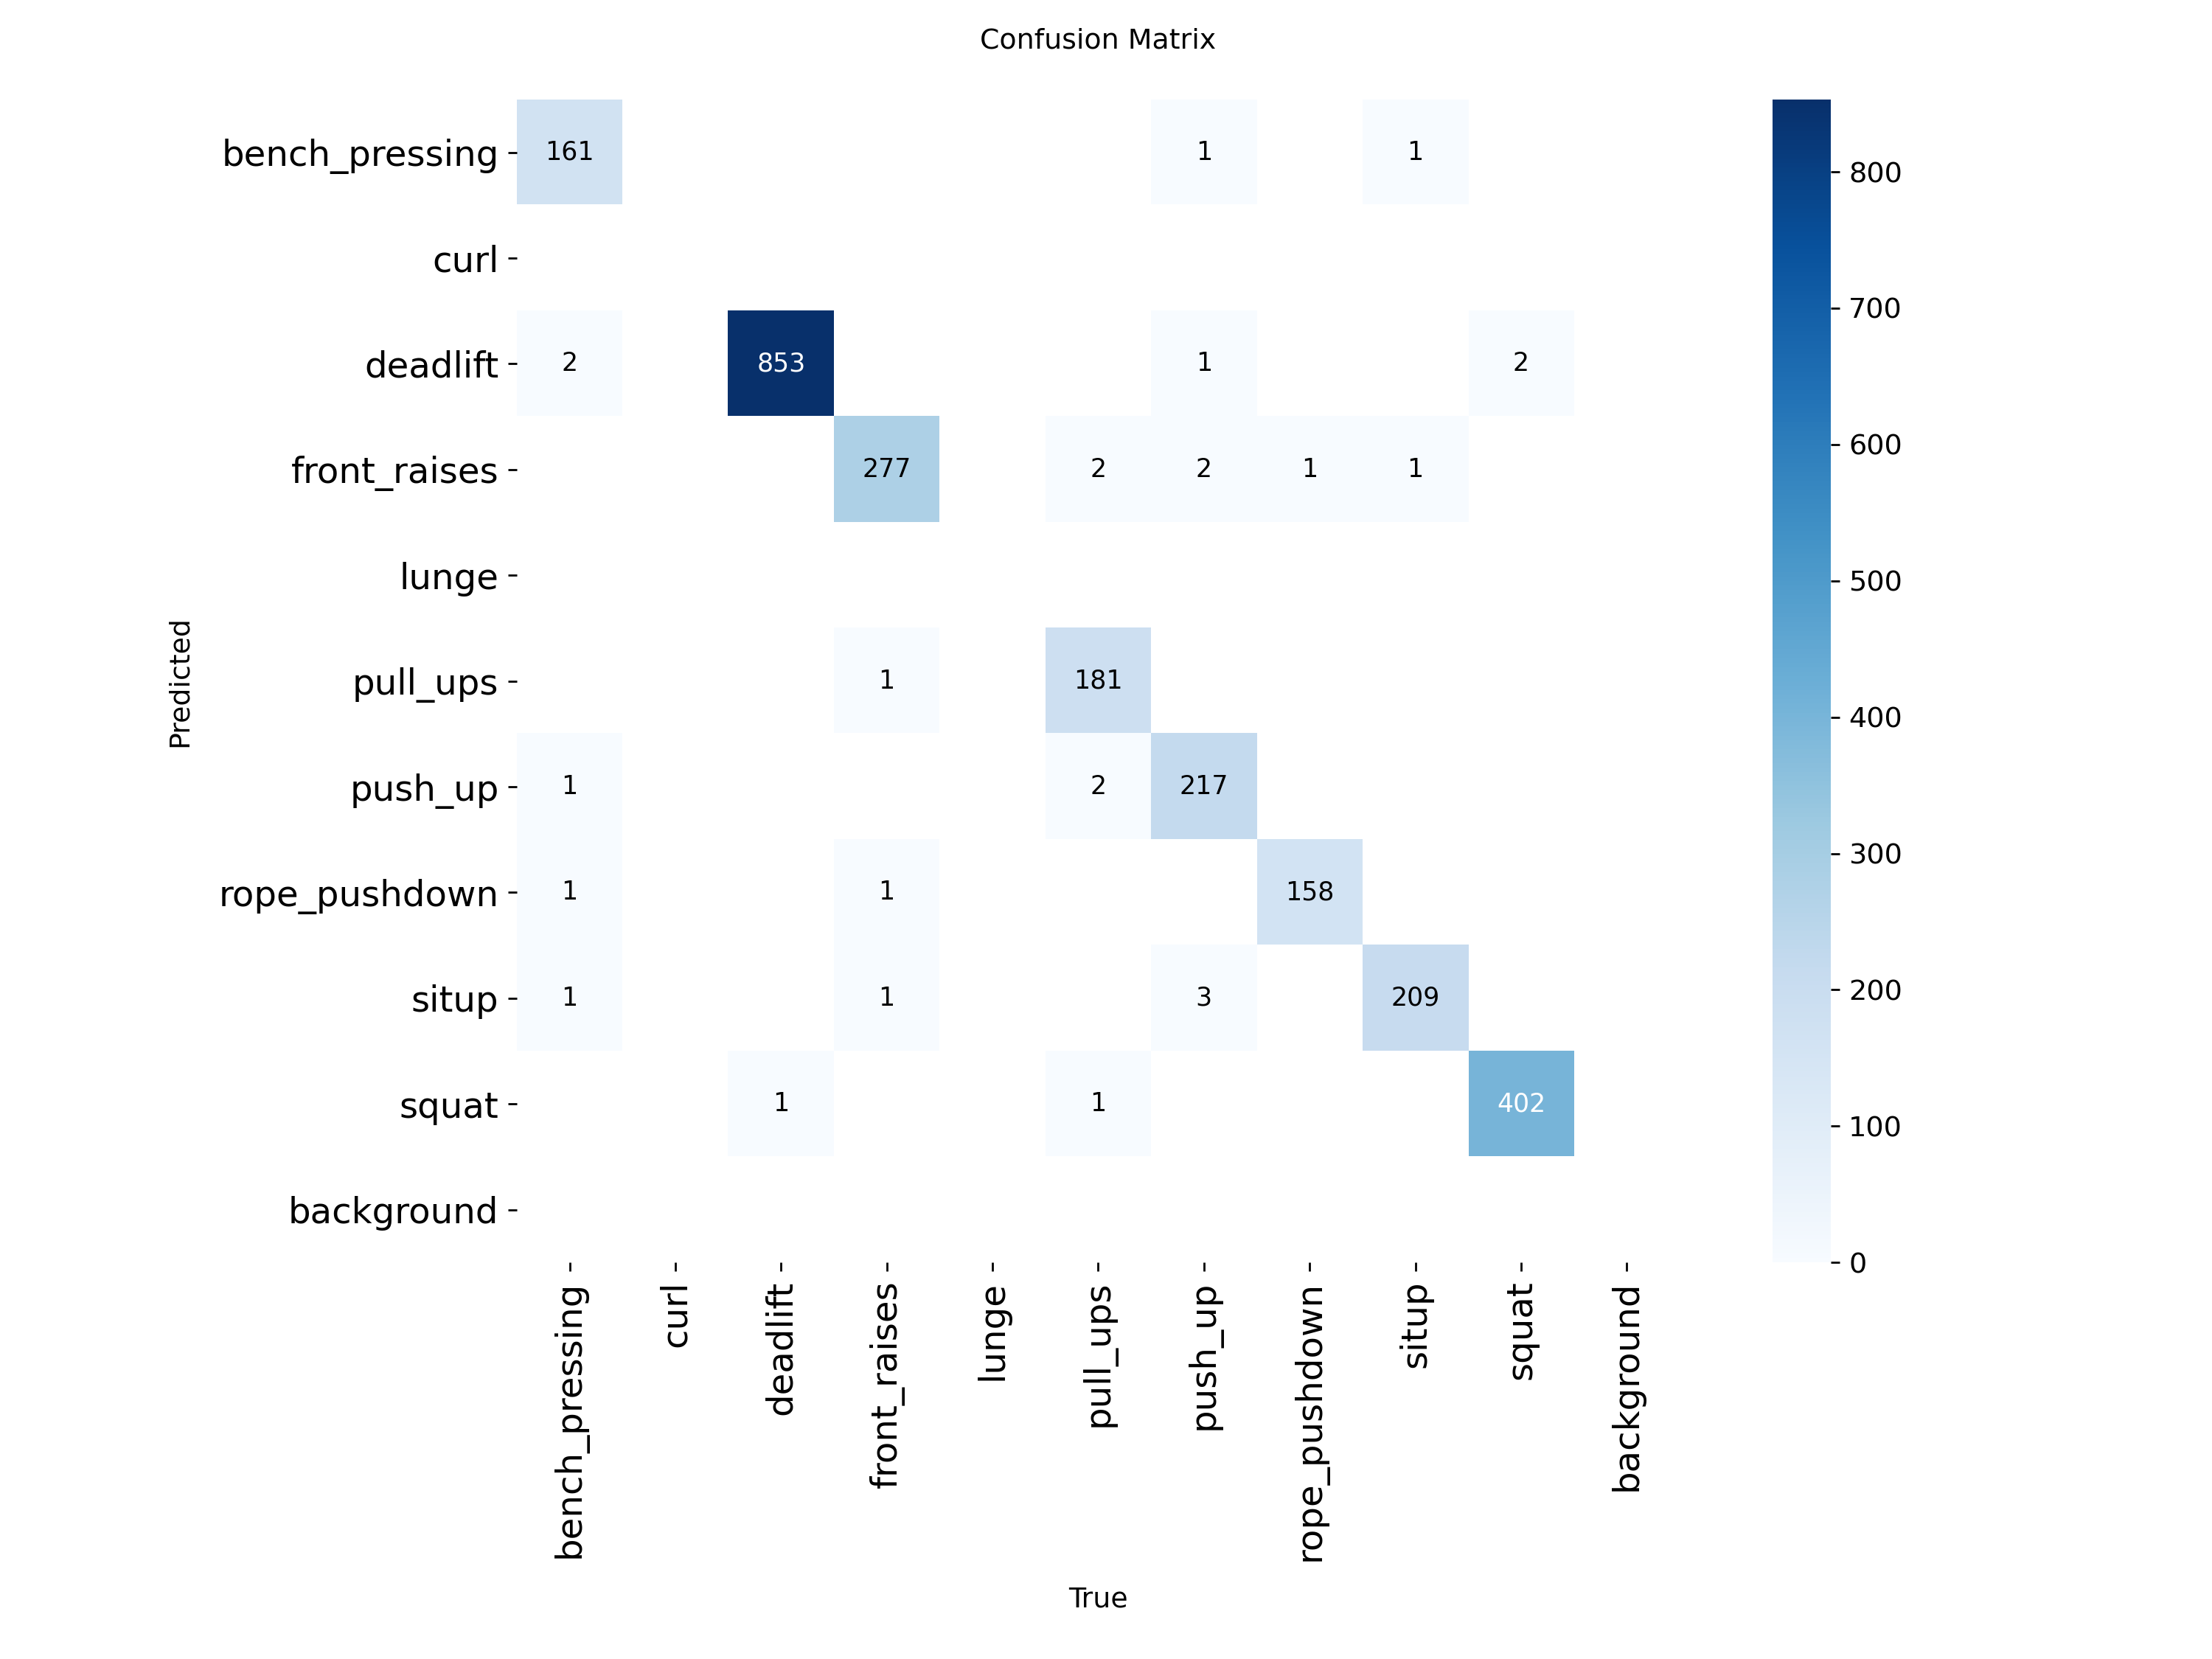


📊 val_batch0_pred.jpg


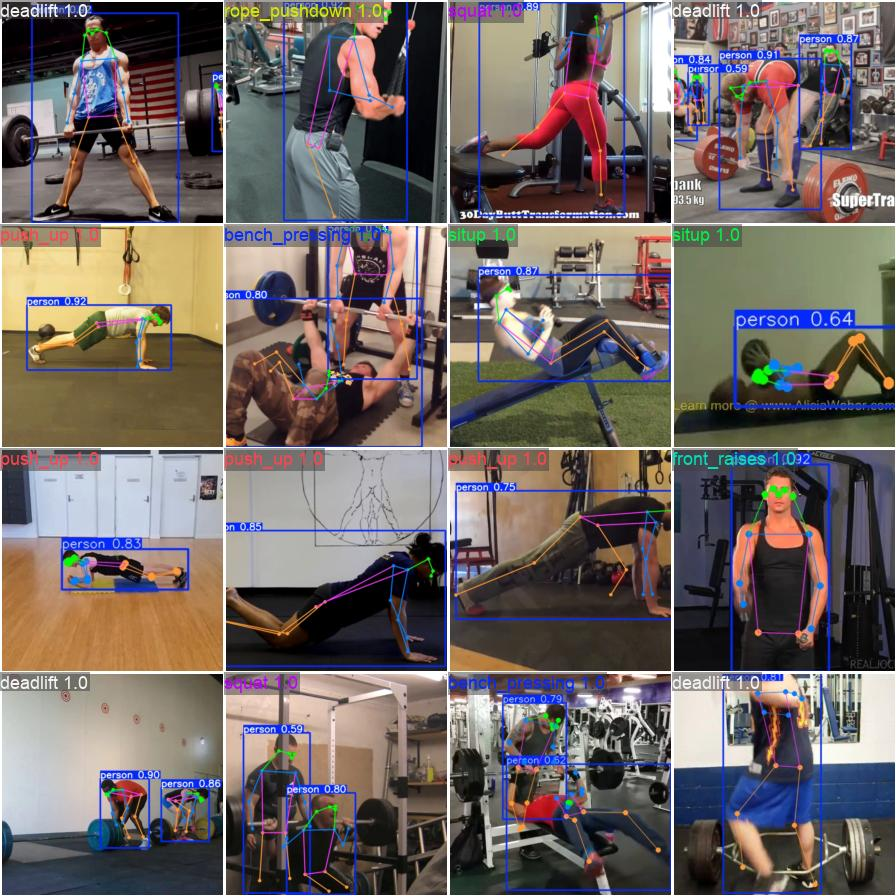


📊 val_batch1_pred.jpg


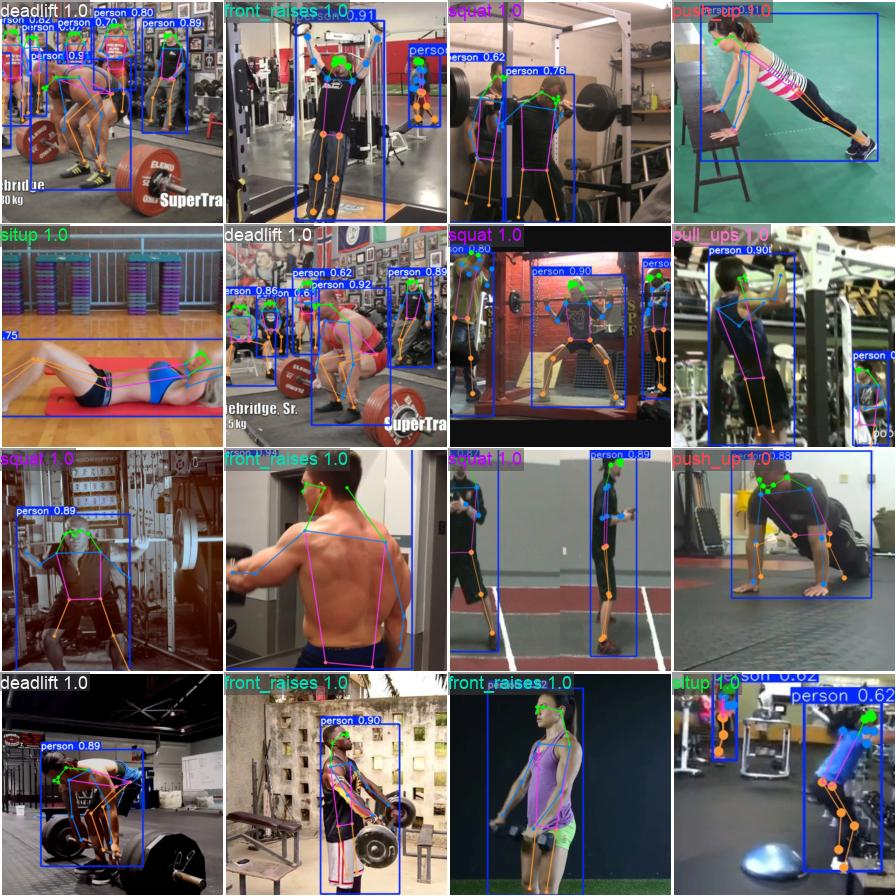

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image as IPImage

run_dir = Path(PROJECT) / EXP_NAME

# Danh sách các biểu đồ Ultralytics tự tạo
plot_files = [
    "results.png",
    "confusion_matrix_normalized.png",
    "confusion_matrix.png",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
]

for fname in plot_files:
    fpath = run_dir / fname
    if fpath.exists():
        print(f"\n📊 {fname}")
        display(IPImage(filename=str(fpath)))
    else:
        print(f"[INFO] Chưa tìm thấy: {fname}")

Các cột trong results.csv:
['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


/tmp/ipykernel_106/4001545381.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


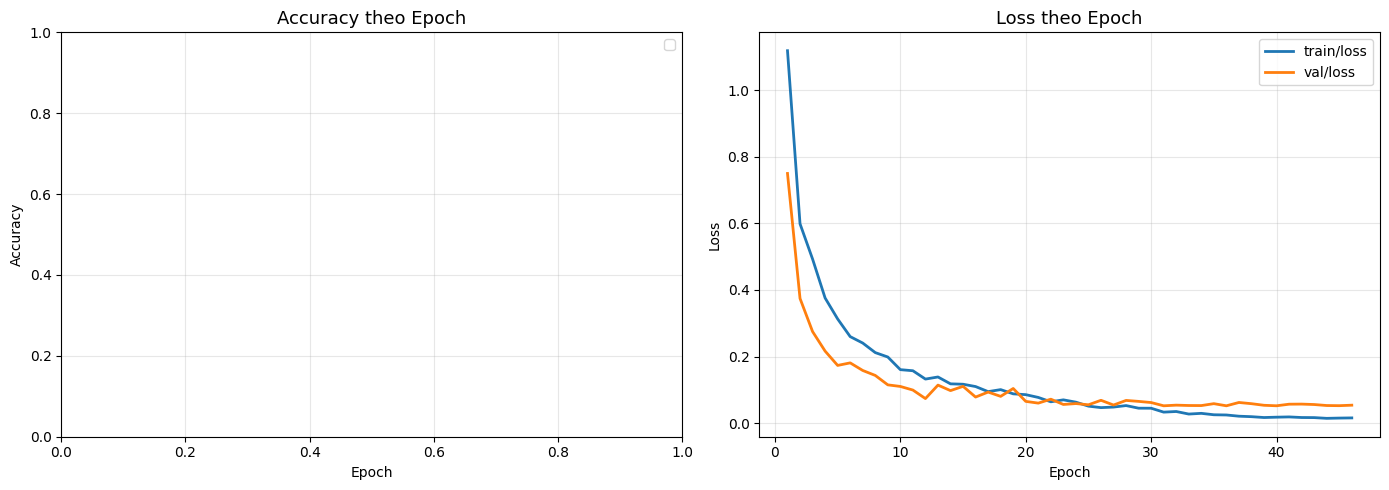

✅ Biểu đồ đã lưu.


In [15]:
# ── Vẽ đường cong accuracy & loss từ CSV ──────────────────────
import pandas as pd

csv_path = run_dir / "results.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()   # loại bỏ khoảng trắng thừa

    print("Các cột trong results.csv:")
    print(df.columns.tolist())

    # Xác định tên cột (có thể khác nhau giữa các phiên bản Ultralytics)
    acc_top1_col = next((c for c in df.columns if "top1" in c.lower() and "val" in c.lower()), None)
    acc_top5_col = next((c for c in df.columns if "top5" in c.lower() and "val" in c.lower()), None)
    loss_cols    = [c for c in df.columns if "loss" in c.lower()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy ──
    ax = axes[0]
    if acc_top1_col:
        ax.plot(df["epoch"], df[acc_top1_col], label="Top-1 Acc (val)", linewidth=2)
    if acc_top5_col:
        ax.plot(df["epoch"], df[acc_top5_col], label="Top-5 Acc (val)", linewidth=2, linestyle="--")
    ax.set_title("Accuracy theo Epoch", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Loss ──
    ax = axes[1]
    for lc in loss_cols:
        ax.plot(df["epoch"], df[lc], label=lc, linewidth=2)
    ax.set_title("Loss theo Epoch", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(run_dir / "custom_training_curves.png", dpi=150)
    plt.show()
    print("✅ Biểu đồ đã lưu.")
else:
    print(f"[WARN] Không tìm thấy results.csv tại: {csv_path}")

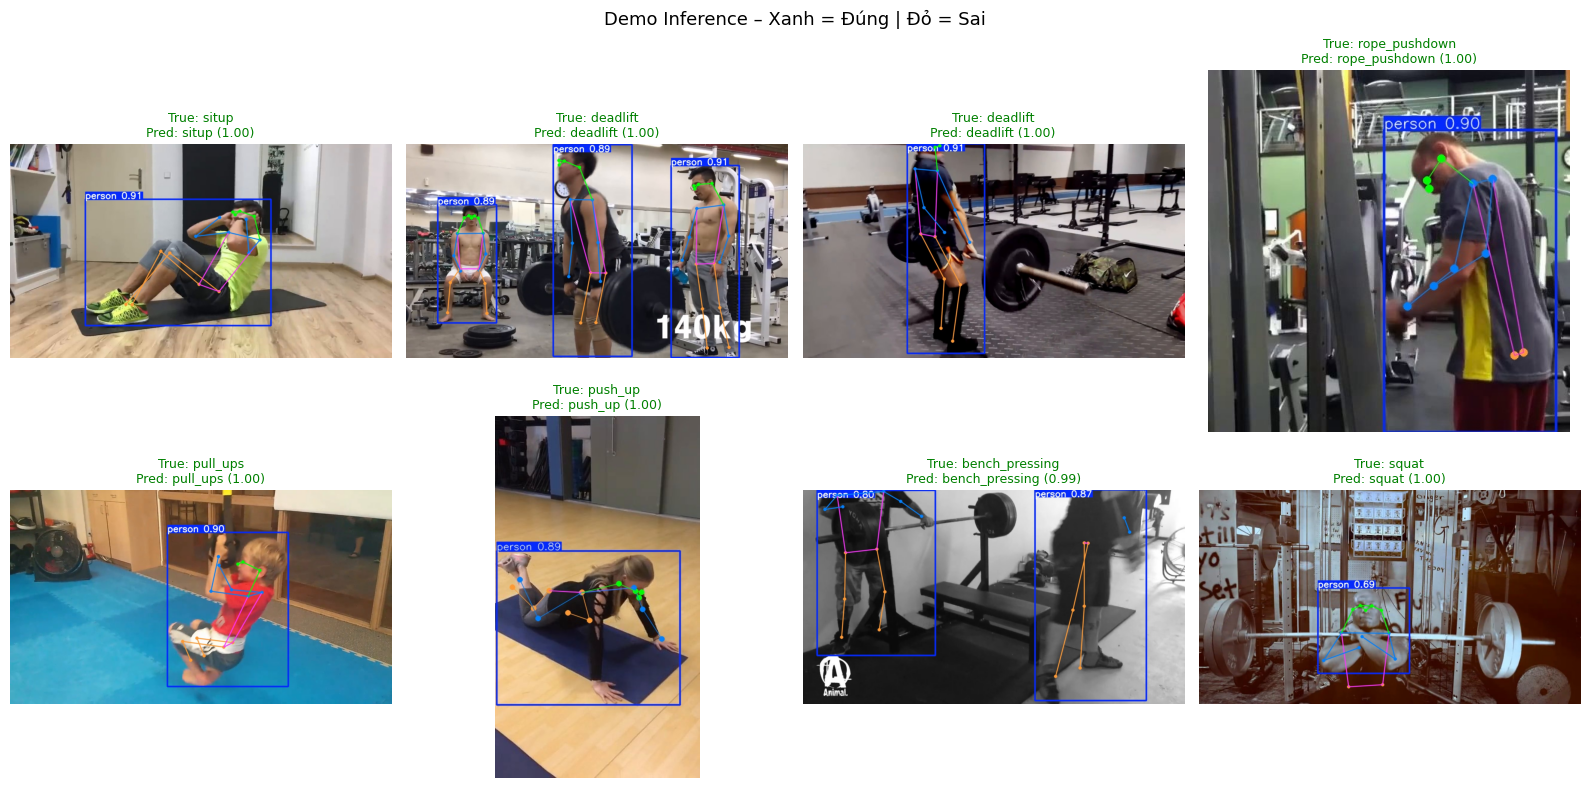

✅ Demo inference hoàn tất.


In [16]:
# ── Demo Inference trên một số ảnh test ───────────────────────
import random
import numpy as np

# Lấy ngẫu nhiên 8 ảnh từ test set
test_images = []
for cls_folder in (CLS_DIR / "test").iterdir():
    if cls_folder.is_dir():
        imgs = list(cls_folder.glob("*.jpg")) + list(cls_folder.glob("*.png"))
        test_images.extend(imgs[:2])   # lấy 2 ảnh mỗi class

random.shuffle(test_images)
demo_images = test_images[:8]

if demo_images:
    # Inference
    preds = best_model.predict(demo_images, imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    # Vẽ kết quả
    n = len(demo_images)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).flatten()

    for i, (img_path, pred) in enumerate(zip(demo_images, preds)):
        true_cls  = img_path.parent.name
        top1_idx  = int(pred.probs.top1)
        top1_conf = float(pred.probs.top1conf)
        pred_cls  = pred.names[top1_idx]

        img = mpimg.imread(str(img_path))
        axes[i].imshow(img)
        color = "green" if pred_cls == true_cls else "red"
        axes[i].set_title(
            f"True: {true_cls}\nPred: {pred_cls} ({top1_conf:.2f})",
            color=color, fontsize=9
        )
        axes[i].axis("off")

    # Ẩn các subplot thừa
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Demo Inference – Xanh = Đúng | Đỏ = Sai", fontsize=13)
    plt.tight_layout()
    fig.savefig(run_dir / "demo_inference.png", dpi=150)
    plt.show()
    print("✅ Demo inference hoàn tất.")
else:
    print("[WARN] Không có ảnh test để demo.")

In [17]:
# ── Tóm tắt kết quả cuối cùng ─────────────────────────────────
print("\n" + "=" * 55)
print("           📊 TÓM TẮT KẾT QUẢ HUẤN LUYỆN")
print("=" * 55)
print(f"Model         : {MODEL_NAME}")
print(f"Epochs        : {EPOCHS}")
print(f"Image size    : {IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Num classes   : {NUM_CLASSES}")
print(f"Classes       : {CLASS_NAMES}")
print("-" * 55)
try:
    print(f"Val  Top-1 Acc: {val_metrics.top1:.4f} ({val_metrics.top1 * 100:.2f}%)")
    print(f"Val  Top-5 Acc: {val_metrics.top5:.4f} ({val_metrics.top5 * 100:.2f}%)")
except Exception:
    pass
try:
    print(f"Test Top-1 Acc: {test_metrics.top1:.4f} ({test_metrics.top1 * 100:.2f}%)")
    print(f"Test Top-5 Acc: {test_metrics.top5:.4f} ({test_metrics.top5 * 100:.2f}%)")
except Exception:
    pass
print("-" * 55)
print(f"Best weights  : {best_model_path}")
print(f"Results dir   : {run_dir}")
print("=" * 55)


           📊 TÓM TẮT KẾT QUẢ HUẤN LUYỆN
Model         : yolov8s-cls.pt
Epochs        : 50
Image size    : 224
Batch size    : 32
Num classes   : 10
Classes       : {0: 'bench_pressing', 1: 'front_raises', 2: 'pull_ups', 3: 'push_up', 4: 'situp', 5: 'rope_pushdown', 6: 'deadlift', 7: 'lunge', 8: 'curl', 9: 'squat'}
-------------------------------------------------------
Val  Top-1 Acc: 0.9895 (98.95%)
Val  Top-5 Acc: 0.9992 (99.92%)
Test Top-1 Acc: 0.9851 (98.51%)
Test Top-5 Acc: 0.9988 (99.88%)
-------------------------------------------------------
Best weights  : /kaggle/working/runs/classify/fitness_yolo_cls/weights/best.pt
Results dir   : /kaggle/working/runs/classify/fitness_yolo_cls


---

## 📌 Ghi chú & Hướng dẫn tuỳ chỉnh

### Thay đổi model
```python
MODEL_NAME = "yolo11s-cls.pt"   # YOLO11 mới nhất
MODEL_NAME = "yolov8m-cls.pt"   # YOLOv8 Medium
```

### Tăng hiệu suất
- Tăng `EPOCHS` lên 100–200 nếu có nhiều thời gian  
- Thử `IMG_SIZE = 320` hoặc `448` để giữ chi tiết ảnh hơn  
- Bật `amp=True` trong `.train()` để dùng Mixed Precision (tiết kiệm VRAM)  

### Export model
```python
# Export sang ONNX để deploy
best_model.export(format="onnx", imgsz=IMG_SIZE)

# Export sang TorchScript
best_model.export(format="torchscript")
```

### Inference trên ảnh mới
```python
results = best_model.predict(
    source="path/to/image.jpg",
    imgsz=224,
    verbose=False,
)
for r in results:
    print(r.names[r.probs.top1], r.probs.top1conf.item())
```